<a href="https://colab.research.google.com/github/deltorobarba/astrophysics/blob/main/missions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Astrophysical Data Sources**

![sciences](https://raw.githubusercontent.com/deltorobarba/repo/master/sciences_2000.png)

Code pipeline to query **IRSA** (Infrared, Near-Infrared), **HEASARC** (Ultraviolet, X-Ray, Gamma Ray)

*Author: Alexander Del Toro Barba, PhD*

In [ ]:
!pip install astropy astroquery matplotlib numpy requests -q

#### **Define astronomical object and get skycoordinates**

*First choose an astronomical object (e.g. galaxy, nebula, star) and query its coordinates*

In [ ]:
# Define object
object_name = 'M31'
# Alternatives: 'Abell 2125'

In [ ]:
# Get and set skycoordinates of object
from astroquery.simbad import Simbad
from astropy.coordinates import SkyCoord

skyobject = Simbad.query_object(object_name)
ra_hms = skyobject['RA'][0]
dec_dms = skyobject['DEC'][0]
coord = SkyCoord(ra=ra_hms, dec=dec_dms, unit=('hourangle', 'deg'), frame='icrs')
print(skyobject)
print("\nCoordinates:")
print("RA (h:m:s):", ra_hms)
print("DEC (d:m:s):", dec_dms)

MAIN_ID      RA          DEC      RA_PREC ... COO_WAVELENGTH     COO_BIBCODE     SCRIPT_NUMBER_ID
          "h:m:s"      "d:m:s"            ...                                                    
------- ------------ ------------ ------- ... -------------- ------------------- ----------------
  M  31 00 42 44.330 +41 16 07.50       7 ...              I 2006AJ....131.1163S                1

Coordinates:
RA (h:m:s): 00 42 44.330
DEC (d:m:s): +41 16 07.50


In [ ]:
# Convert from Right Ascension (RA) and Declination (DEC) to decimal degree
coord = SkyCoord(ra=ra_hms, dec=dec_dms, unit=('hourangle', 'deg'), frame='icrs')
ra_deg = coord.ra.deg # round(coord.ra.deg, 2)
dec_deg = coord.dec.deg # round(coord.dec.deg, 2)

print("RA in degrees:", ra_deg)
print("DEC in degrees:", dec_deg)

RA in degrees: 10.684708333333331
DEC in degrees: 41.26875


In [ ]:
# Convert from decimal degree to Right Ascension (RA) and Declination (DEC)
coord = SkyCoord(ra=ra_deg, dec=dec_deg, unit='deg', frame='icrs')

# RA: hours, minutes, seconds. DEC: degrees, arcminutes, arcseconds
ra_hms = coord.ra.to_string(unit='hour', sep=' ', precision=3, pad=True)
dec_dms = coord.dec.to_string(unit='deg', sep=' ', precision=2, alwayssign=True, pad=True)

print("RA (h:m:s):", ra_hms)
print("DEC (d:m:s):", dec_dms)

RA (h:m:s): 00 42 44.330
DEC (d:m:s): +41 16 07.50


In [ ]:
# Reverse check to see to which object the coordinates belong
coord = SkyCoord(ra=ra_hms, dec=dec_dms, unit=('hourangle', 'deg'), frame='icrs')
result = Simbad.query_region(coord, radius='0d0m5s')  # Search within a small radius (5 arcseconds)
if result:
    print(result['MAIN_ID'][0])  # Show the main name of the object
else:
    print("No object found in SIMBAD at these coordinates.")
object_name = 'MAIN_ID'

M  31


#### **NRAO and ATNF (Radio Astronomy)**

Yes! Both NRAO (National Radio Astronomy Observatory) and ATNF (Australia Telescope National Facility) data are more readily accessible through Python tools. Here are the main ways:

For NRAO:
```python
from astroquery.nrao import Nrao

# Search for VLA data
result = Nrao.query_region("M87", radius="0.5 deg",
                          telescope="EVLA",  # or other NRAO telescopes
                          freq_band="L")     # Frequency band

# For the VLA archive specifically
from astroquery.vla import Vla
# Note: VLA queries require authentication
```

For ATNF (particularly the Pulsar Catalogue):
```python
from astroquery.atnf import Atnf

# Query the pulsar catalog
# ou can specify parameters like period, distance, etc.
pulsar_table = Atnf.query_catalog(
    params=['JNAME', 'RAJ', 'DECJ', 'P0', 'DM'],
    condition='P0 < 0.1 && DM > 10'  # Example conditions
)

# Get info for a specific pulsar
pulsar = Atnf.get_pulsar('J0534+2200')  # Crab Pulsar
```

For general radio astronomy data:
```python
# Using the Virtual Observatory (VO)
from astroquery.vo_conesearch import ConeSearch
from astropy.coordinates import SkyCoord
import astropy.units as u

# Define position
coord = SkyCoord('12h29m06.7s +02d03m08.7s', frame='icrs')

# Search catalogues
result = ConeSearch.query_region(
    coord,
    radius=0.5 * u.deg,
    catalog_db="ivo://CDS/VIII/62A/atlas"  # Radio source catalog
)
```

Some other useful tools for radio astronomy in Python:
1. `casa` (Common Astronomy Software Applications)
```python
import casatools
import casatasks

Example of loading a measurement set
ms = casatools.ms()
ms.open('your_data.ms')
```

2. `spectral-cube` for working with radio data cubes:
```python
from spectral_cube import SpectralCube
cube = SpectralCube.read('your_cube.fits')
```

Would you like me to elaborate on any particular aspect or show more specific examples for a certain type of analysis?

In [2]:
from astroquery.atnf import Atnf

# Query the pulsar catalog
# You can specify parameters like period, distance, etc.
pulsar_table = Atnf.query_catalog(
    params=['JNAME', 'RAJ', 'DECJ', 'P0', 'DM'],
    condition='P0 < 0.1 && DM > 10'  # Example conditions
)

# Get info for a specific pulsar
pulsar = Atnf.get_pulsar('J0534+2200')  # Crab Pulsar

ModuleNotFoundError: No module named 'astroquery.atnf'

#### **HEASARC (Ultraviolet, X-Ray, Gamma Ray)**

HEASARC (High Energy Astrophysics Science Archive Research Center): data from missions observing the high-energy universe, like X-rays and gamma rays. Like black holes, supernovas, and active galaxies
* Missions: Chandra, XMM-Newton, Swift, Fermi, NuSTAR
* Website: heasarc.gsfc.nasa.gov

https://github.com/deltorobarba/astrophysics/blob/main/star_A0620_00.ipynb

In [ ]:
# Query all available missions from library
from astroquery.heasarc import Heasarc
heasarc = Heasarc()
missions = heasarc.query_mission_list()
print(missions)

 Mission     Table                                  Table Description                               
---------- ---------- ------------------------------------------------------------------------------
     AGILE   agilecat                       First AGILE Catalog of High-Confidence Gamma-Ray Sources
     AGILE agileupvar              Updated AGILE Catalog of Bright Gamma-Ray Sources and Variability
     AKARI   akaribsc                      AKARI/FIS All-Sky Survey Bright Source Catalog, Version 1
     AKARI   akaripsc                       AKARI/IRC All-Sky Survey Point Source Catalog, Version 1
       ANS ansuvpscat                            ANS Ultraviolet Photometry Catalog of Point Sources
   ARIEL V    ariel3a                                                        3rd Ariel-V SSI Catalog
   ARIEL V     ariel5                                                        Ariel V All-Sky Monitor
      ASCA ascaegclus                           ASCA Elliptical Galaxies and Galaxy Cluster

In [ ]:
# Select mission
mission='chanmaster'

Main X-ray missions:
- `chanmaster`: Chandra Master Catalog
- `csc2master`: Chandra Source Catalog 2.0
- `xmmmaster`: XMM-Newton Master Catalog
- `xmmssc`: XMM-Newton Serendipitous Source Catalog
- `swiftmastr`: Swift Master Catalog
- `swiftxrtspec`: Swift-XRT Spectral Database
- `rass2rxs`: ROSAT All-Sky Survey Catalogs
- `exomaster`: EXOSAT Master Catalog
- `numaster`: NuSTAR Master Catalog

For other wavelengths/multi-wavelength:
- `fermimastr`: Fermi Master Catalog (gamma-ray)
- `intmaster`: INTEGRAL Master Catalog (gamma-ray)
- `suzamaster`: Suzaku Master Catalog
- `hstadvize`: Hubble Space Telescope Pointed Observations (optical)
- `jwstmaster`: James Webb Space Telescope Master Catalog (infrared)

In [ ]:
# Query observations from one mission (PI - Principal Investigator. Lead scientist for observation)
chanmaster_data = heasarc.query_object('*', mission)
print(chanmaster_data)

OBSID        STATUS        ...                    PI                    PUBLIC_DATE
                           ...                                              mjd    
----- -------------------- ... ---------------------------------------- -----------
 6616 archived             ... Miller                                         54159
 7587 archived             ... Canizares                                      54502
28092 untriggered          ... Canizares                                          0
29852 untriggered          ... Canizares                                          0
28354 unobserved           ... Kargaltsev                                         0
30481 untriggered          ... Canizares                                          0
28775 untriggered          ... Canizares                                          0
13814 archived             ... Kuntz                                          56576
13842 archived             ... Baganoff                                     

In [ ]:
# Query a specific object in mission
object_data = heasarc.query_object(object_name, mission='chanmaster')
print(object_data)

OBSID        STATUS        ... PUBLIC_DATE SEARCH_OFFSET_
                           ...     mjd                   
----- -------------------- ... ----------- --------------
15562 archived             ...       56965  1.017 (M31)\n
15273 archived             ...       56948  1.000 (M31)\n
15275 archived             ...       56965  1.017 (M31)\n
15277 archived             ...       56945  0.953 (M31)\n
15274 archived             ...       56948  1.000 (M31)\n
15276 archived             ...       56965  1.017 (M31)\n
15278 archived             ...       56945  0.953 (M31)\n
15561 archived             ...       56948  1.000 (M31)\n
15563 archived             ...       56945  0.953 (M31)\n
  ...                  ... ...         ...            ...
  273 archived             ...       52095  0.019 (M31)\n
  278 archived             ...       52242  0.019 (M31)\n
 2904 archived             ...       52604  0.019 (M31)\n
 1570 archived             ...       52464  0.019 (M31)\n
 1569 archived

In [ ]:
# Reduce to specific columns for object
specific_data = heasarc.query_object(object_name, mission='chanmaster', fields='OBSID,ra,dec,exposure')
print(specific_data)

OBSID    RA      DEC    EXPOSURE SEARCH_OFFSET_
        deg      deg       s                   
----- -------- -------- -------- --------------
15562 10.70250 41.25833    77130  1.017 (M31)\n
15273 10.68458 41.28542    77060  1.000 (M31)\n
15275 10.70250 41.25833    77060  1.017 (M31)\n
15277 10.66875 41.25833    74770  0.953 (M31)\n
15274 10.68458 41.28542    73560  1.000 (M31)\n
15276 10.70250 41.25833    73500  1.017 (M31)\n
15278 10.66875 41.25833    72740  0.953 (M31)\n
15561 10.68458 41.28542    70560  1.000 (M31)\n
15563 10.66875 41.25833    69900  0.953 (M31)\n
  ...      ...      ...      ...            ...
  273 10.68500 41.26897     1200  0.019 (M31)\n
  278 10.68500 41.26897     1190  0.019 (M31)\n
 2904 10.68500 41.26897     1190  0.019 (M31)\n
 1570 10.68500 41.26897     1190  0.019 (M31)\n
 1569 10.68500 41.26897     1190  0.019 (M31)\n
  277 10.68500 41.26897     1190  0.019 (M31)\n
  276 10.68500 41.26897     1190  0.019 (M31)\n
  275 10.68500 41.26897     1190  0.019 

In [ ]:
# Initialize the Heasarc class
heasarc = Heasarc()

# Coordinates for galaxy
coord = SkyCoord(ra=ra_hms, dec=dec_dms, unit=('hourangle', 'deg'), frame='icrs')
# coord = SkyCoord(ra="15h41m14.8s", dec="+66d16m03s", unit=('hourangle', 'deg'), frame='icrs')

# Query Chandra data
# Using 'chanmaster' for the Chandra Master Catalog
chandra_result = heasarc.query_region(
    coord,
    mission='chanmaster',
    radius='0.2 deg'  # Increased radius to ensure we catch all relevant observations
)

# Print the result
if chandra_result is not None and len(chandra_result) > 0:
    print(f"Found {len(chandra_result)} Chandra observations")
    for obs in chandra_result:
        print(f"\nObservation ID: {obs['OBSID']}")
        print(f"Exposure Time: {obs['EXPOSURE']} seconds")
else:
    print("No Chandra observations found")

Found 212 Chandra observations

Observation ID: 15562
Exposure Time: 77130.0 seconds

Observation ID: 15275
Exposure Time: 77060.0 seconds

Observation ID: 15273
Exposure Time: 77060.0 seconds

Observation ID: 15277
Exposure Time: 74770.0 seconds

Observation ID: 15274
Exposure Time: 73560.0 seconds

Observation ID: 15276
Exposure Time: 73500.0 seconds

Observation ID: 15278
Exposure Time: 72740.0 seconds

Observation ID: 15561
Exposure Time: 70560.0 seconds

Observation ID: 15563
Exposure Time: 69900.0 seconds

Observation ID: 11252
Exposure Time: 58870.0 seconds

Observation ID: 14196
Exposure Time: 53830.0 seconds

Observation ID: 13827
Exposure Time: 51880.0 seconds

Observation ID: 13825
Exposure Time: 49980.0 seconds

Observation ID: 13828
Exposure Time: 49880.0 seconds

Observation ID: 14198
Exposure Time: 49870.0 seconds

Observation ID: 1912
Exposure Time: 46970.0 seconds

Observation ID: 14197
Exposure Time: 46850.0 seconds

Observation ID: 5925
Exposure Time: 46680.0 seconds

#### **IRSA (Infrared, Near-Infrared)**

IRSA (Infrared Science Archive): This archive focuses on infrared data, which reveals cooler objects in space, like dust clouds where stars are born, distant galaxies, and planets in our solar system
* Spitzer, WISE, Herschel, SOFIA
* Website: irsa.ipac.caltech.edu

The **IRSA Catalog** refers to the astronomical data and resources provided by the **Infrared Science Archive (IRSA)**. IRSA is an essential facility hosted by NASA, tasked with curating and distributing infrared astronomical data collected from missions and projects. It enables astronomers to search for and access large-scale datasets related to infrared observations of celestial objects.

1. **Infrared Data**: IRSA focuses on data in the infrared spectrum, which allows astronomers to study phenomena such as:
   - Star formation.
   - Interstellar dust and gas.
   - Galaxy formation and evolution.
   - Objects obscured in visible light by dust.

2. **Access to Multiple Missions**: IRSA provides access to data from several missions, such as:
   - **Spitzer Space Telescope** (e.g., GLIMPSE, SEIP catalogs).
   - **WISE (Wide-field Infrared Survey Explorer)** and its catalogs.
   - **2MASS (Two Micron All-Sky Survey)** catalog.
   - **SOFIA (Stratospheric Observatory for Infrared Astronomy)** data.
   - **Planck** and more.

3. **Data Search and Retrieval Tools**:
   - **Gator**: A catalog search engine to query and filter data based on astronomical criteria.
   - **IRSA Viewer**: A tool for visualizing infrared images and overlaying catalogs.
   - **VO (Virtual Observatory) Tools**: Interoperable tools for accessing and analyzing data.

4. **Application**:
   - Study of celestial objects (stars, galaxies, planetary systems).
   - Analysis of large-scale cosmic structures.
   - Identification of exoplanets, brown dwarfs, and asteroids.
   - Examining regions of the universe hidden in optical wavelengths.

The IRSA catalogs support astrophysical research by enabling detailed analysis of phenomena that are not accessible in visible light. For example:
- Infrared observations are crucial for understanding star formation in dense molecular clouds.
- It helps in identifying distant galaxies obscured by interstellar dust.

Researchers can use IRSA tools to retrieve photometric data, spectra, and imaging for studies ranging from nearby planetary systems to the most distant observable galaxies.

https://astroquery.readthedocs.io/en/latest/ipac/irsa/irsa.html

https://astroquery.readthedocs.io/projects/keflavich-astroquery/en/latest/irsa.html

In [ ]:
# Query all available missions from library
from astroquery.ipac.irsa import Irsa
catalogs = Irsa.list_catalogs()
print(catalogs)

{'pt_src_6x2': "2MASS 6X w/LMC/SMC Point Source Working Database / Catalog (<a href='/applications/Gator/GatorAid/2MASS/6xcat.README.html' target='doc'>README</a>)", 'sixxf_info': '2MASS 6X w/LMC/SMC Merged Point Source Information Table', 'sixxf_link': '2MASS 6X w/LMC/SMC Merged Point Source Link Table', 'ext_src_6x2': "2MASS 6X w/LMC/SMC Extended Source Working Database / Catalog (<a href='/applications/Gator/GatorAid/2MASS/6xcat.README.html' target='doc'>README</a>)", 'esixxf_info': '2MASS 6X w/LMC/SMC Merged Extended Source Information Table', 'esixxf_link': '2MASS 6X w/LMC/SMC Merged Extended Source Link Table', 'pscan_dat_6x2': '2MASS 6X w/LMC/SMC Scan Info', 'coadd_dat_6x2': '2MASS 6X w/LMC/SMC Atlas Image Info', 'twomass.sixx_full_images': "2MASS Six-times (6x) Full Images (<a href='/applications/Radar/IM/2massImg.html' target='doc'>README</a>)", 'twomass.sixx_catalog_images': "2MASS Six-times (6x) Catalog Images (<a href='/applications/Radar/IM/2massImg.html' target='doc'>READ

In [ ]:
Irsa.list_collections()

collection
object
akari_allskymaps
blast
bolocam_gps
bolocam_lh
bolocam_planck_sz
champ
cosmos
euclid_ero
goals


In [ ]:
# Queries over a polygon
#table = Irsa.query_region(object_name, catalog="fp_psc", spatial="Polygon",
#polygon=[coord.SkyCoord(ra=10.1, dec=10.1, unit=(u.deg, u.deg), frame='icrs'),
#         coord.SkyCoord(ra=10.0, dec=10.1, unit=(u.deg, u.deg), frame='icrs'),
#         coord.SkyCoord(ra=10.0, dec=10.0, unit=(u.deg, u.deg), frame='icrs')
#        ])
#print(table)

In [ ]:
# Selecting columns
table = Irsa.query_region(object_name, catalog="allwise_p3as_psd", spatial="Cone", columns="ra,dec,w1mpro")
print(table)

    ra        dec     w1mpro
   deg        deg      mag  
---------- ---------- ------
10.6846947 41.2689392  5.819


In [ ]:
# Direct TAP query to the IRSA server
query = ("SELECT TOP 10 ra,dec,j_m,j_msigcom,h_m,h_msigcom,k_m,k_msigcom,ph_qual,cc_flg "
         "FROM fp_psc WHERE CONTAINS(POINT('ICRS',ra, dec), CIRCLE('ICRS',10.6846947,41.2689392,5.819))=1")
#          "FROM fp_psc WHERE CONTAINS(POINT('ICRS',ra, dec), CIRCLE('ICRS',202.48417,47.23056,0.4))=1")
results = Irsa.query_tap(query=query).to_qtable()
results

/usr/local/lib/python3.10/dist-packages/pyvo/dal/query.py:339: DALOverflowWarning: Partial result set. Potential causes MAXREC, async storage space, etc.
  warn("Partial result set. Potential causes MAXREC, async storage space, etc.",


ra,dec,j_m,j_msigcom,h_m,h_msigcom,k_m,k_msigcom,ph_qual,cc_flg
deg,deg,mag,mag,mag,mag,mag,mag,,
float64,float64,float32,float32,float32,float32,float32,float32,object,object
17.182749,43.699284,16.484,0.105,15.971,0.145,15.949,0.236,BBD,000
17.198810,43.716602,15.869,0.065,15.295,0.090,15.174,0.123,AAB,000
17.190077,43.718616,14.606,0.031,13.990,0.033,13.763,0.037,AAA,000
17.198377,43.714397,16.412,0.097,15.796,0.138,15.752,0.182,ABC,000
17.174449,43.714855,15.046,0.039,14.365,0.044,14.352,0.063,AAA,000
17.186766,43.715275,15.655,0.059,15.427,0.090,15.548,0.163,AAC,000
17.189046,43.706406,16.128,0.088,15.689,0.111,15.572,0.172,ABC,000
17.205421,43.752987,12.666,0.022,12.145,0.022,12.072,0.021,AAA,000


In [ ]:
# Reverse check if coordinate belong to correct object
coord = SkyCoord(ra=ra_hms, dec=dec_dms, unit=('hourangle', 'deg'), frame='icrs')
result = Simbad.query_region(coord, radius='0d0m5s')  # Search within a small radius (5 arcseconds)
if result:
    print(result['MAIN_ID'][0])  # Show the main name of the object
else:
    print("No object found in SIMBAD at these coordinates.")

M  31


In [ ]:
# Filter for a specific catalog (e.g. Spitzer)
spitzer_catalogs = {key: value for key, value in catalogs.items() if 'spitzer' in key}
print(spitzer_catalogs)

{'spitzer.seip_images': 'Spitzer Enhanced Imaging Products (SEIP) Images', 'spitzer.seip_science': 'Spitzer SEIP Science Image Metadata', 'spitzer.seip_ancillary': 'Spitzer SEIP Ancillary Image Metadata', 'spitzer.abell1763_images': 'Abell 1763 Images', 'spitzer.c2d_images_irac_all': 'Spitzer C2D IRAC Image Metadata', 'spitzer.c2d_images_mips_all': 'Spitzer C2D MIPS Image Metadata', 'spitzer.c2d_images_av': 'Spitzer C2D AV Image Metadata', 'spitzer.c2d_images_bolocam': 'Spitzer C2D Bolocam Image Metadata', 'spitzer.c2d_images': 'C2D Images', 'spitzer.c2d_irac_iv_caom_core': 'Spitzer C2D IRAC Image (Image/per Band) Metadata', 'spitzer.c2d_mips_caom_nofilter': 'Spitzer C2D MIPS (Image/Per Band) Image Metadata', 'spitzer.c2d_irs_cubes': 'Spitzer C2D IRS Cubes', 'spitzer.c2d_irs_spec': 'C2D IRS Spectra', 'spitzer.clash_images': 'Cluster Lensing And Supernova survey with Hubble (CLASH) Images', 'spitzer.cosmic_dawn': 'Cosmic Dawn Survey Data', 'spitzer.cygnus_x_images': 'A Spitzer Legacy Su

In [ ]:
# Select catalog or mission
collection = 'spitzer_seip'

**Infrared Surveys (images and catalogs)**
* Spitzer Source Catalogs:
    * `seip_science`: The source catalog from SEIP
    * `spitzer_c2d`: Catalog from the c2d Legacy Survey
    * `spitzer_glimpse`: Catalog from the GLIMPSE Survey
* Spitzer Image Collections (used with query_sia):
    * `spitzer_seip`: Enhanced Imaging Products
    * `spitzer_sha`: Spitzer Heritage Archive
    * `spitzer_c2d`: c2d Legacy Survey Images
    * `spitzer_glimpse`: GLIMPSE Survey Images
* WISE Source Catalogs:
    * `allwise`: The AllWISE Source Catalog (combines data from WISE All-Sky, 3-Band Cryo, and Post-Cryo surveys)
    * `wise_allsky`: The original WISE All-Sky Release Source Catalog
    * `neowise`: NEOWISE-R Single Exposure Source Database
* WISE Image Collections (used with query_sia):
    * `wise_allwise`: AllWISE Atlas Images
    * `wise_allsky`: WISE All-Sky Release Atlas Images
    * `wise_neowiser`: NEOWISE-R Atlas Images
* 2MASS Source Catalogs:
    * `fp_psc`: 2MASS Point Source Catalog
    * `fp_xsc`: 2MASS Extended Source Catalog
* 2MASS Image Collections:
    * `2mass`: 2MASS All-Sky Atlas Images
* IRAS Source Catalogs:
    * `iras_psc`: IRAS Point Source Catalog
    * `iras_fsc`: IRAS Faint Source Catalog

**Near-Infrared Surveys**
* 2MASS Source Catalogs:
    * `fp_psc`: 2MASS Point Source Catalog
    * `fp_xsc`: 2MASS Extended Source Catalog
* 2MASS Image Collections:
    * `2mass`: 2MASS Atlas Images
* UKIDSS Source Catalogs:
    * `ukidss`: UKIRT Infrared Deep Sky Survey Catalog
* UKIDSS Image Collections:
    * `ukidss_las`: UKIDSS Large Area Survey Images
    * `ukidss_gcs`: UKIDSS Galactic Clusters Survey Images

**Dust/Galactic Structure**
* IRAS Source Catalogs:
    * `iras_psc`: IRAS Point Source Catalog
    * `iras_fsc`: IRAS Faint Source Catalog
* IRAS Image Collections:
    * `issa`: IRAS Sky Survey Atlas Images
* Dust Maps:
    * `irsa_dust`: IRAS/COBE Dust Maps (catalog-like service)

**Recent/Ongoing Surveys**
* NEOWISE Catalogs:
    * `neowise`: NEOWISE-R Single Exposure Source Database
* NEOWISE Images:
    * `wise_neowiser`: NEOWISE-R Atlas Images
* unWISE Catalogs:
    * `unwise`: unWISE Source Catalog
* unWISE Images:
    * `unwise_atlas`: unWISE Atlas Images
* COSMOS Catalogs:
    * `cosmos`: COSMOS Source Catalog
* COSMOS Images:
    * `cosmos_tiles`: COSMOS Survey Tiles

**Specific Scientific Studies**
* PTF Catalogs:
    * `ptf`: Palomar Transient Factory Source Catalog
* PTF Images:
    * `ptf_images`: PTF Survey Images
* GOALS Data:
    * `mass_goals`: Great Observatories All-sky LIRG Survey Catalog
* AKARI Catalogs:
    * `akari`: AKARI/IRC Point Source Catalogue
* AKARI Images:
    * `akari_images`: AKARI Survey Images

*Note: Not all collections have both catalog and image services available. Some might only provide catalogs, while others might only provide images or have different access methods.*

*Note: IRSA's Simple Image Access (SIA) protocol to find images. It searches within 1 arcminute radius around your specified coordinates. The query returns metadata about available images in that region.*

*Note: The main difference between AllWISE and WISE All-Sky is that AllWISE combines multiple surveys and provides improved sensitivity and accuracy compared to the original WISE All-Sky Survey.*

*Query IRSA Catalog Data (not images)*

In [ ]:
# Option 1: Display available data by searching for the object name
from astropy import units as u

catalog = "fp_psc" # change collection / catalogue for this request

table = Irsa.query_region(object_name, catalog=catalog, spatial="Cone",
                          radius=2 * u.arcmin)
print(table)

    ra       dec    err_maj err_min err_ang ... ext_key scan_key coadd_key coadd        htm20       
   deg       deg     arcsec  arcsec   deg   ...                                                     
--------- --------- ------- ------- ------- ... ------- -------- --------- ----- -------------------
10.692216 41.260162    0.10    0.09      87 ...      --    69157   1590591    33 4805203678124326400
10.700059 41.263481    0.31    0.30     155 ...      --    69157   1590591    33 4805203678125364736
10.699131 41.263248    0.28    0.20      82 ...      --    69157   1590591    33 4805203678125474304
10.697569 41.261272    0.11    0.10      90 ...      --    69157   1590591    33 4805203678125530624
10.703106 41.252998    0.16    0.14      21 ...      --    69157   1590591    33 4805203678126695936
10.703557 41.252811    0.14    0.13     111 ...      --    69157   1590591    33 4805203678126795776
10.704491 41.252598    0.15    0.14      24 ...      --    69157   1590591    33 4805203678

In [ ]:
coord = SkyCoord(ra_deg, dec_deg, unit='deg', frame='galactic')
table = Irsa.query_region(coordinates=coord,
                          catalog='fp_psc', radius='0d2m0s')
print(table)

    ra       dec    err_maj err_min err_ang ... ext_key scan_key coadd_key coadd        htm20       
   deg       deg     arcsec  arcsec   deg   ...                                                     
---------- -------- ------- ------- ------- ... ------- -------- --------- ----- -------------------
237.004404 2.751914    0.27    0.25     179 ...      --    53725   1235665   150 4803753526738309120
237.003187 2.737467    0.09    0.08       0 ...      --    53725   1235665   150 4803753526788968960
237.015384 2.732973    0.48    0.33      84 ...      --    53725   1235665   150 4803753526799783424
236.995817 2.709317    0.07    0.06      11 ... 1974214    53724   1235640   127 4803753526822579712


In [ ]:
# Option 2: Display available data by searching using coordinates of galaxy
ra = 121.1743
dec = -21.5733
coord = SkyCoord(ra, dec, unit='deg', frame='galactic')
table = Irsa.query_region(coordinates=coord, catalog='fp_psc', radius='0d2m0s')
print(table)

    ra       dec    err_maj err_min err_ang ... ext_key scan_key coadd_key coadd        htm20       
   deg       deg     arcsec  arcsec   deg   ...                                                     
--------- --------- ------- ------- ------- ... ------- -------- --------- ----- -------------------
10.692216 41.260162    0.10    0.09      87 ...      --    69157   1590591    33 4805203678124326400
10.700059 41.263481    0.31    0.30     155 ...      --    69157   1590591    33 4805203678125364736
10.699131 41.263248    0.28    0.20      82 ...      --    69157   1590591    33 4805203678125474304
10.697569 41.261272    0.11    0.10      90 ...      --    69157   1590591    33 4805203678125530624
10.703106 41.252998    0.16    0.14      21 ...      --    69157   1590591    33 4805203678126695936
10.703557 41.252811    0.14    0.13     111 ...      --    69157   1590591    33 4805203678126795776
10.704491 41.252598    0.15    0.14      24 ...      --    69157   1590591    33 4805203678

*Query IRSA Images Data*

In [ ]:
# Option 3: Access IMAGES with IRSA-SIA from IRSA for object images (in 'coord') from a given telescope (in 'collection')
from astropy import units as u

obj_details = Irsa.query_sia(
    pos=(coord, 1 * u.arcmin),  # Position and search radius
    collection=collection    # Specifying the collection
)
obj_details

<DALResultsTable length=0>
  s_ra   s_dec  facility_name instrument_name ... pol_xel cloud_access o_ucd  upload_row_id
  deg     deg                                 ...                                          
float64 float64     object         object     ...  int64     object    object     int64    
------- ------- ------------- --------------- ... ------- ------------ ------ -------------

In [ ]:
# Turn details into a table
images = Irsa.query_sia(pos=(coord, 1 * u.arcmin), collection=collection).to_table()
images[:3] # show only first 3 results

s_ra,s_dec,facility_name,instrument_name,dataproduct_subtype,calib_level,dataproduct_type,energy_bandpassname,energy_emband,obs_id,s_resolution,em_min,em_max,em_res_power,proposal_title,access_url,access_format,access_estsize,t_exptime,s_region,obs_collection,obs_intent,algorithm_name,facility_keywords,instrument_keywords,environment_photometric,proposal_id,proposal_pi,proposal_project,target_name,target_type,target_standard,target_moving,target_keywords,obs_release_date,s_xel1,s_xel2,s_pixel_scale,position_timedependent,t_min,t_max,t_resolution,t_xel,obs_publisher_did,s_fov,em_xel,pol_states,pol_xel,cloud_access,o_ucd,upload_row_id
deg,deg,,,,,,,,,arcsec,m,m,,,,,kbyte,s,deg,,,,,,,,,,,,,,,,,,arcsec,,d,d,s,,,deg,,,,,,
float64,float64,object,object,object,int16,object,object,object,object,float64,float64,float64,float64,object,object,object,int64,float64,object,object,object,object,object,object,bool,object,object,object,object,object,bool,bool,object,object,int64,int64,float64,bool,float64,float64,float64,int64,object,float64,int64,object,int64,object,object,int64
10.6551277,41.413963,Spitzer Space Telescope,IRAC,noise,3,image,IRAC3,Infrared,50072571.50072571-54.IRAC,1.88,5.02e-06,6.41e-06,4.2,Spitzer Enhanced Imaging Products,https://irsa.ipac.caltech.edu/data/SPITZER/Enhanced/SEIP/images/5/0072/50072571/4/50072571-54/50072571.50072571-54.IRAC.3.std.fits,image/fits,83368,--,POLYGON ICRS 11.1580944 41.031617 11.1640364 41.7942579 10.1459973 41.7942584 10.1519381 41.0316175 11.1580944 41.031617,spitzer_seip,science,mosaic,,,--,,,Spitzer,,field,False,False,,2013-12-19 00:00:00,4554,4576,0.600012,False,--,--,--,--,ivo://irsa.ipac/spitzer_seip/50072571.50072571-54.IRAC,0.7608463411172756,--,,--,"{""aws"": {""bucket_name"": ""nasa-irsa-spitzer"", ""key"":""spitzer/seip/seip_science/images/5/0072/50072571/4/50072571-54/50072571.50072571-54.IRAC.3.std.fits"", ""region"": ""us-west-2""}}",,1
10.6551277,41.413963,Spitzer Space Telescope,IRAC,noise,3,image,IRAC3,Infrared,50072571.50072571-54.IRAC,1.88,5.02e-06,6.41e-06,4.2,Spitzer Enhanced Imaging Products,https://irsa.ipac.caltech.edu/data/SPITZER/Enhanced/SEIP/images/5/0072/50072571/4/50072571-54/50072571.50072571-54.IRAC.3.median_mosaic_unc.fits,image/fits,83368,--,POLYGON ICRS 11.1580944 41.031617 11.1640364 41.7942579 10.1459973 41.7942584 10.1519381 41.0316175 11.1580944 41.031617,spitzer_seip,science,mosaic,,,--,,,Spitzer,,field,False,False,,2013-12-19 00:00:00,4554,4576,0.600012,False,--,--,--,--,ivo://irsa.ipac/spitzer_seip/50072571.50072571-54.IRAC,0.7608463411172756,--,,--,"{""aws"": {""bucket_name"": ""nasa-irsa-spitzer"", ""key"":""spitzer/seip/seip_science/images/5/0072/50072571/4/50072571-54/50072571.50072571-54.IRAC.3.median_mosaic_unc.fits"", ""region"": ""us-west-2""}}",,1
10.6551277,41.413963,Spitzer Space Telescope,IRAC,weight,3,image,IRAC3,Infrared,50072571.50072571-54.IRAC,1.88,5.02e-06,6.41e-06,4.2,Spitzer Enhanced Imaging Products,https://irsa.ipac.caltech.edu/data/SPITZER/Enhanced/SEIP/images/5/0072/50072571/4/50072571-54/50072571.50072571-54.IRAC.3.cov.fits,image/fits,83368,--,POLYGON ICRS 11.1580944 41.031617 11.1640364 41.7942579 10.1459973 41.7942584 10.1519381 41.0316175 11.1580944 41.031617,spitzer_seip,science,mosaic,,,--,,,Spitzer,,field,False,False,,2013-12-19 00:00:00,4554,4576,0.600012,False,--,--,--,--,ivo://irsa.ipac/spitzer_seip/50072571.50072571-54.IRAC,0.7608463411172756,--,,--,"{""aws"": {""bucket_name"": ""nasa-irsa-spitzer"", ""key"":""spitzer/seip/seip_science/images/5/0072/50072571/4/50072571-54/50072571.50072571-54.IRAC.3.cov.fits"", ""region"": ""us-west-2""}}",,1


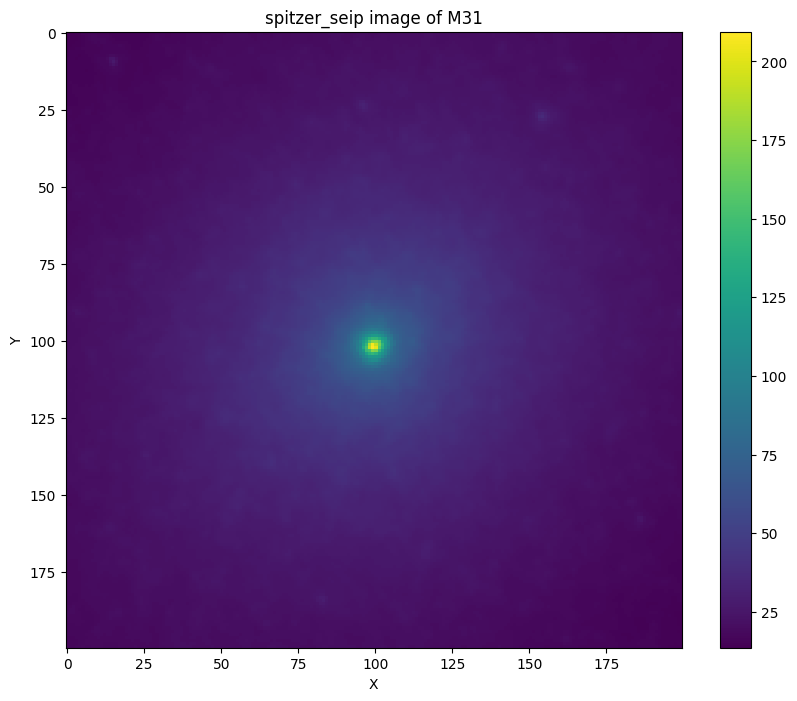

(<matplotlib.image.AxesImage at 0x78fd7b5dbfd0>,
 None)

In [ ]:
# Open cutout image for one science image
from astropy.io import fits
from astropy.nddata import Cutout2D
from astropy.wcs import WCS
import matplotlib.pyplot as plt

images = Irsa.query_sia(pos=(coord, 1 * u.arcmin), collection=collection).to_table()
image = images[images['dataproduct_subtype'] == 'science'][0]
with fits.open(image['access_url'], use_fsspec=True) as hdul:
    cutout = Cutout2D(hdul[0].section, position=coord, size=2 * u.arcmin, wcs=WCS(hdul[0].header))

plt.figure(figsize=(10, 8)).add_subplot().set(title=f'{collection} image of {object_name}', xlabel='X', ylabel='Y')
plt.imshow(cutout.data, cmap='viridis'), plt.colorbar(), plt.show()

In [ ]:
# How many science picture are there in the catalog for the specific object?
science_images_count = len(images[images['dataproduct_subtype'] == 'science'])
print("Number of science images:", science_images_count)

Number of science images: 32


 [astropy.io.fits.verify]

 [astropy.io.fits.verify]



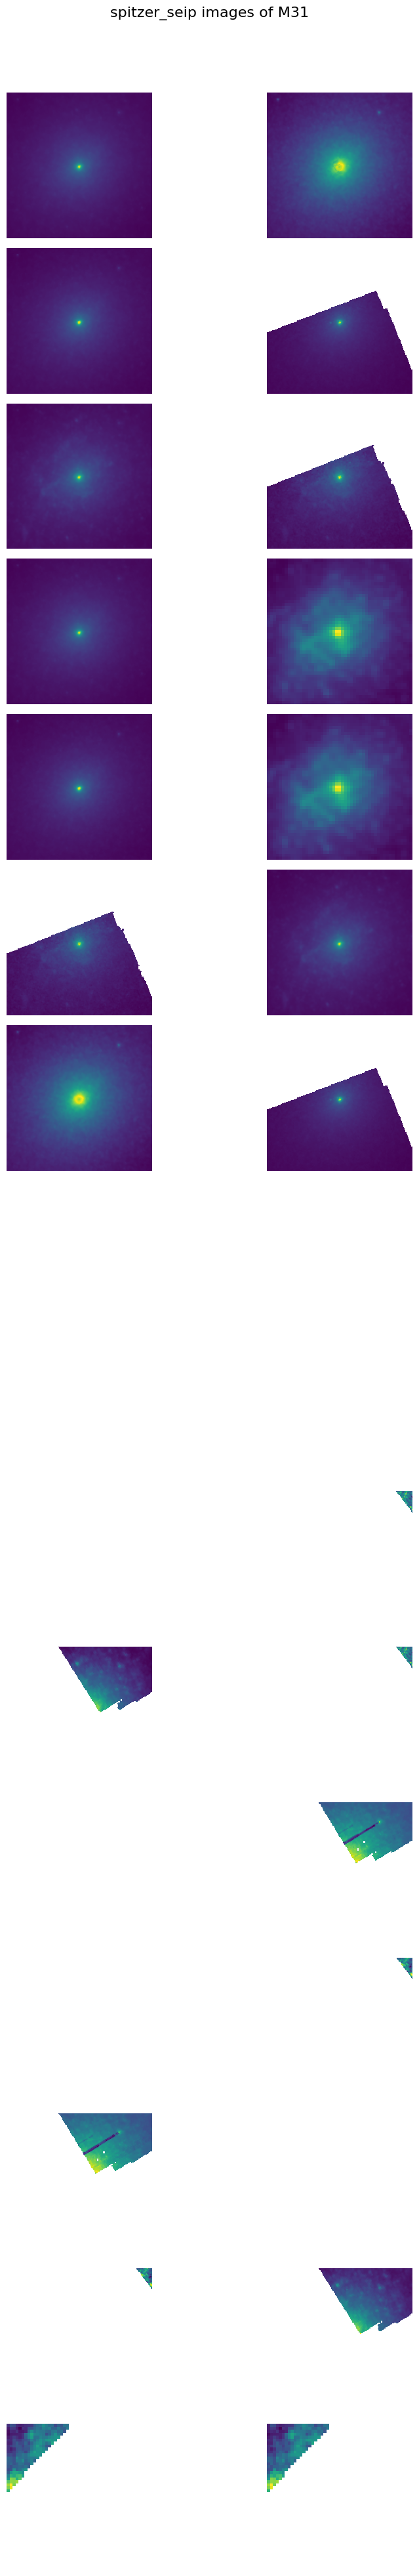

In [ ]:
# Simple image access queries from IRSA for object images from telescope
coord = SkyCoord(ra=ra_hms, dec=dec_dms, unit=('hourangle', 'deg'), frame='icrs')
spitzer_images = Irsa.query_sia(pos=(coord, 1 * u.arcmin), collection='spitzer_seip').to_table()

# Filter for science images only
science_images = spitzer_images[spitzer_images['dataproduct_subtype'] == 'science']

# Set up the figure for a grid (2 images per row, total number of images/2 rows)

n_rows = len(science_images) // 2  # Integer division to get half the count
fig, axes = plt.subplots(n_rows, 2, figsize=(10, 2.5 * n_rows))  # Adjust figsize proportionally

# Loop through each of the science images of the images
for i in range(science_images_count):
    # Access each science image URL
    science_image = science_images[i]
    with fits.open(science_image['access_url'], use_fsspec=True) as hdul:
        cutout = Cutout2D(hdul[0].section, position=coord, size=2 * u.arcmin, wcs=WCS(hdul[0].header))

    # Plot the cutout in the grid
    ax = axes[i // 2, i % 2]  # Calculate row and column for 2 images per row
    ax.imshow(cutout.data, cmap='viridis')
    ax.axis('off')  # Hide axes for clarity

plt.suptitle(f'{collection} images of {object_name}', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout for the title
plt.show()



---



In [ ]:
# Query the SEIP source catalog
seip_sources = Irsa.query_region(coord, catalog='seip_science', radius=1*u.arcmin)

In [ ]:
# For catalog queries:
allwise_sources = Irsa.query_region(coord, catalog='allwise', radius=1*u.arcmin)
wise_allsky_sources = Irsa.query_region(coord, catalog='wise_allsky', radius=1*u.arcmin)

# For image queries:
allwise_images = Irsa.query_sia(pos=(coord, 1*u.arcmin), collection='wise_allwise')
wise_allsky_images = Irsa.query_sia(pos=(coord, 1*u.arcmin), collection='wise_allsky')

#### **MAST (Optical/Visible)**

In [ ]:
from astroquery.mast import Observations
import astropy.units as u
from astropy.coordinates import SkyCoord

# Example: Query observations of M51 (Whirlpool Galaxy)
# Define coordinates for M51
coords = SkyCoord('13h29m52.7s +47d11m43s', unit=(u.hourangle, u.deg))

# Search for observations within 0.2 degrees of these coordinates
radius = 0.2 * u.deg
obs_table = Observations.query_region(coords, radius=radius)

# Print basic information about the first few observations
print(f"Found {len(obs_table)} observations")
print("\nFirst few entries:")
for obs in obs_table[:3]:
    print(f"Target: {obs['target_name']}")
    print(f"Instrument: {obs['instrument_name']}")
    print(f"Filter: {obs['filters']}")
    print("---")

# Optional: Download data products for a specific observation
# obs_id = obs_table[0]['obsid']
# data_products = Observations.get_product_list(obs_id)
# downloaded_files = Observations.download_products(data_products[0])

Found 38835 observations

First few entries:
Target: TESS FFI
Instrument: Photometer
Filter: TESS
---
Target: TESS FFI
Instrument: Photometer
Filter: TESS
---
Target: TESS FFI
Instrument: Photometer
Filter: TESS
---


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.7/210.7 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 39.4 MB/s eta 0:00:00
Querying MAST...
Found observations:
F435W: 107 observations
F555W: 80 observations
F814W: 171 observations



INFO:astroquery:Found cached file ./mastDownload/HST/j97c31rrq/j97c31rrq_drz.fits with expected size 214447680.


INFO: Found cached file ./mastDownload/HST/j97c31rrq/j97c31rrq_drz.fits with expected size 214447680. [astroquery.query]


INFO:astroquery:Found cached file ./mastDownload/HST/j97c31rsq/j97c31rsq_drz.fits with expected size 214395840.


INFO: Found cached file ./mastDownload/HST/j97c31rsq/j97c31rsq_drz.fits with expected size 214395840. [astroquery.query]


INFO:astroquery:Found cached file ./mastDownload/HST/j97c31ruq/j97c31ruq_drz.fits with expected size 214344000.


INFO: Found cached file ./mastDownload/HST/j97c31ruq/j97c31ruq_drz.fits with expected size 214344000. [astroquery.query]

Processing images...
Aligning images...
Normalizing data...
Creating color composite...


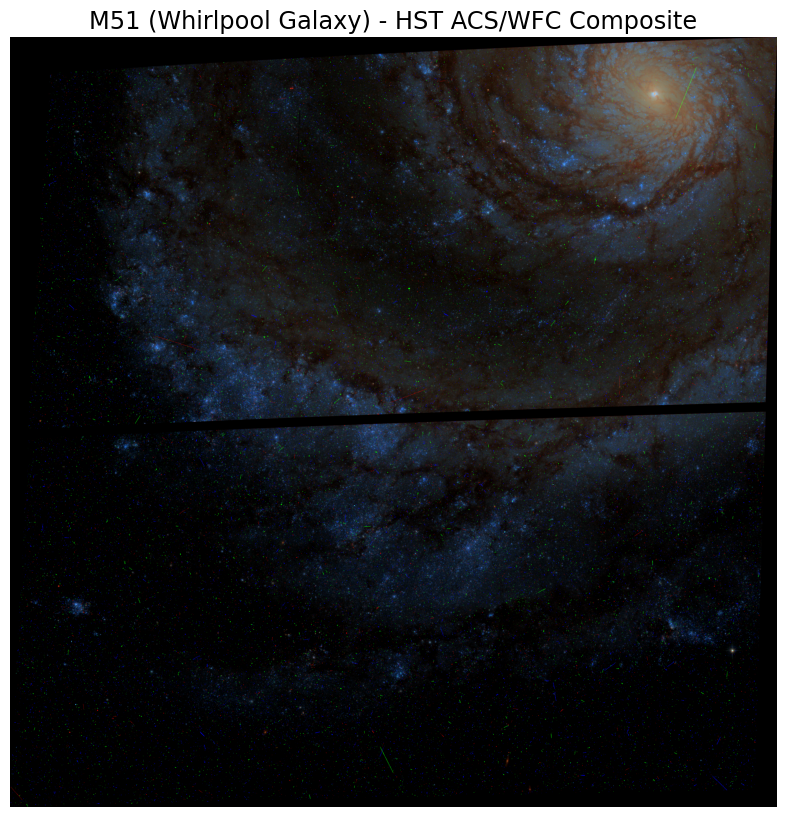


Visualization complete!


In [ ]:
!pip install reproject -q
from astroquery.mast import Observations
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.visualization import make_lupton_rgb
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from reproject import reproject_interp

# Query M51 observations from HST
coords = SkyCoord('13h29m52.7s +47d11m43s', unit=(u.hourangle, u.deg))
radius = 0.2 * u.deg

# Search for observations
print("Querying MAST...")
obs_table = Observations.query_region(coords, radius=radius)

# Filter for HST observations with specific filters
hst_obs = obs_table[obs_table['instrument_name'] == 'ACS/WFC']
f435w = hst_obs[hst_obs['filters'] == 'F435W']
f555w = hst_obs[hst_obs['filters'] == 'F555W']
f814w = hst_obs[hst_obs['filters'] == 'F814W']

print(f"Found observations:")
print(f"F435W: {len(f435w)} observations")
print(f"F555W: {len(f555w)} observations")
print(f"F814W: {len(f814w)} observations")

# Download one observation from each filter
if len(f435w) > 0 and len(f555w) > 0 and len(f814w) > 0:
    print("\nDownloading data products...")
    products_435 = Observations.get_product_list(f435w[0]['obsid'])
    products_555 = Observations.get_product_list(f555w[0]['obsid'])
    products_814 = Observations.get_product_list(f814w[0]['obsid'])

    # Download calibrated files
    files_435 = Observations.download_products(products_435[products_435['productSubGroupDescription'] == 'DRZ'])
    files_555 = Observations.download_products(products_555[products_555['productSubGroupDescription'] == 'DRZ'])
    files_814 = Observations.download_products(products_814[products_814['productSubGroupDescription'] == 'DRZ'])

    print("\nProcessing images...")
    # Read the FITS files with their WCS information
    b_hdu = fits.open(files_435['Local Path'][0])[1]
    g_hdu = fits.open(files_555['Local Path'][0])[1]
    r_hdu = fits.open(files_814['Local Path'][0])[1]

    # Use the first image as reference and reproject others to match
    print("Aligning images...")
    b_reproj, _ = reproject_interp(b_hdu, r_hdu.header)
    g_reproj, _ = reproject_interp(g_hdu, r_hdu.header)
    r_data = r_hdu.data

    # Normalize the data
    def normalize(arr):
        arr = np.nan_to_num(arr, 0)  # Replace NaN with 0
        return arr / np.percentile(arr[arr > 0], 99)

    print("Normalizing data...")
    b_norm = normalize(b_reproj)
    g_norm = normalize(g_reproj)
    r_norm = normalize(r_data)

    # Create RGB image
    print("Creating color composite...")
    rgb = make_lupton_rgb(r_norm, g_norm, b_norm, Q=10, stretch=0.5)

    # Plot
    plt.figure(figsize=(10, 10))
    plt.imshow(rgb, origin='lower')
    plt.title('M51 (Whirlpool Galaxy) - HST ACS/WFC Composite')
    plt.axis('off')
    plt.show()

    print("\nVisualization complete!")
else:
    print("Could not find all required filter observations")

The script includes progress messages so you can track what's happening. Note that:

* The download might take several minutes depending on your connection
* The files are fairly large (several hundred MB in total)
* The image processing might take a minute or two
* The resulting visualization should show M51 in natural-looking colors

**"HST ACS/WFC Composite" means:**

- **HST** = Hubble Space Telescope
- **ACS** = Advanced Camera for Surveys, one of the main instruments aboard Hubble
- **WFC** = Wide Field Channel, a specific detector within ACS that provides a relatively wide field of view
- **Composite** = The image is created by combining data from three different filters:
  - F435W (blue light, roughly B-band)
  - F555W (green light, roughly V-band)
  - F814W (infrared/red light, roughly I-band)

The ACS was installed on Hubble during Servicing Mission 3B in 2002. The Wide Field Channel of ACS was designed for deep, wide-field surveys of the universe. It has a field of view of about 202 x 202 arcseconds and can detect objects roughly a billion times fainter than what the human eye can see.

In our visualization, we're combining data from these three different wavelength filters to create what astronomers call a "false color" image - though in this case, the colors are actually fairly close to what the human eye would see, since we mapped:
- Blue filter (F435W) to the blue channel
- Green filter (F555W) to the green channel
- Red filter (F814W) to the red channel

*Using different filters*

Other filters are available for M51 in the HST observations. This will show us all available filters for each HST instrument that observed M51. For example, besides F435W/F555W/F814W that we used, there might be:
- UV filters (like F275W)
- Different visible light filters (like F606W)
- Near-infrared filters (like F160W)

Each filter lets through light at different wavelengths, which helps astronomers study different aspects of celestial objects:
- UV filters can reveal hot, young stars
- Red and infrared filters are good for seeing dust and older stars
- Narrow-band filters can isolate specific emission lines from gases

Would you like to try making a composite image using a different combination of filters? We could for example try to make a more unusual "false color" image that highlights different features of the galaxy.

In [ ]:
from astroquery.mast import Observations
import astropy.units as u
from astropy.coordinates import SkyCoord

# Query M51 observations from HST
coords = SkyCoord('13h29m52.7s +47d11m43s', unit=(u.hourangle, u.deg))
radius = 0.2 * u.deg

# Search for observations
obs_table = Observations.query_region(coords, radius=radius)

# Get unique combinations of instruments and filters
hst_obs = obs_table[obs_table['obs_collection'] == 'HST']
unique_filters = {}

for obs in hst_obs:
    instrument = obs['instrument_name']
    filt = obs['filters']
    if instrument not in unique_filters:
        unique_filters[instrument] = set()
    if filt:  # Some observations might not have filter info
        unique_filters[instrument].add(filt)

# Print available filters by instrument
for instrument, filters in unique_filters.items():
    print(f"\n{instrument} filters:")
    for f in sorted(filters):
        print(f"  - {f}")


ACS/WFC filters:
  - F330W
  - F435W
  - F502N
  - F555W
  - F606W
  - F658N
  - F660N
  - F775W
  - F814W
  - detection

WFPC2/PC filters:
  - F160BW
  - F218W
  - F255W
  - F300W
  - F336W
  - F439W
  - F450W
  - F502N
  - F547M
  - F555W
  - F606W
  - F656N
  - F675W
  - F814W
  - detection

WFC3/IR filters:
  - BLANK
  - F105W
  - F110W
  - F125W
  - F128N
  - F140W
  - F153M
  - F160W
  - detection

WFC3/UVIS filters:
  - F225W
  - F275W
  - F280N
  - F336W
  - F343N
  - F373N
  - F390M
  - F438W
  - F467M
  - F475W
  - F475X
  - F487N
  - F502N
  - F547M
  - F555W
  - F606W
  - F631N
  - F657N
  - F673N
  - F689M
  - F814W
  - F845M
  - detection

ACS/HRC filters:
  - F220W
  - F250W
  - F330W
  - F555W
  - F775W;CLEAR2L
  - F775W;F330W
  - F814W
  - PR200L
  - detection

STIS filters:
  - G230LB
  - G430L
  - G430L;G430M;G750L
  - G430L;G750M
  - G750M

NICMOS/NIC2 filters:
  - BLANK
  - F110W
  - F160W
  - F187N
  - F190N
  - F205W
  - F212N
  - F215N
  - F216N
  - F222M

NICM

#### **SDSS (Optical/Visible)**

https://github.com/deltorobarba/astrophysics/blob/main/nebula_M42.ipynb

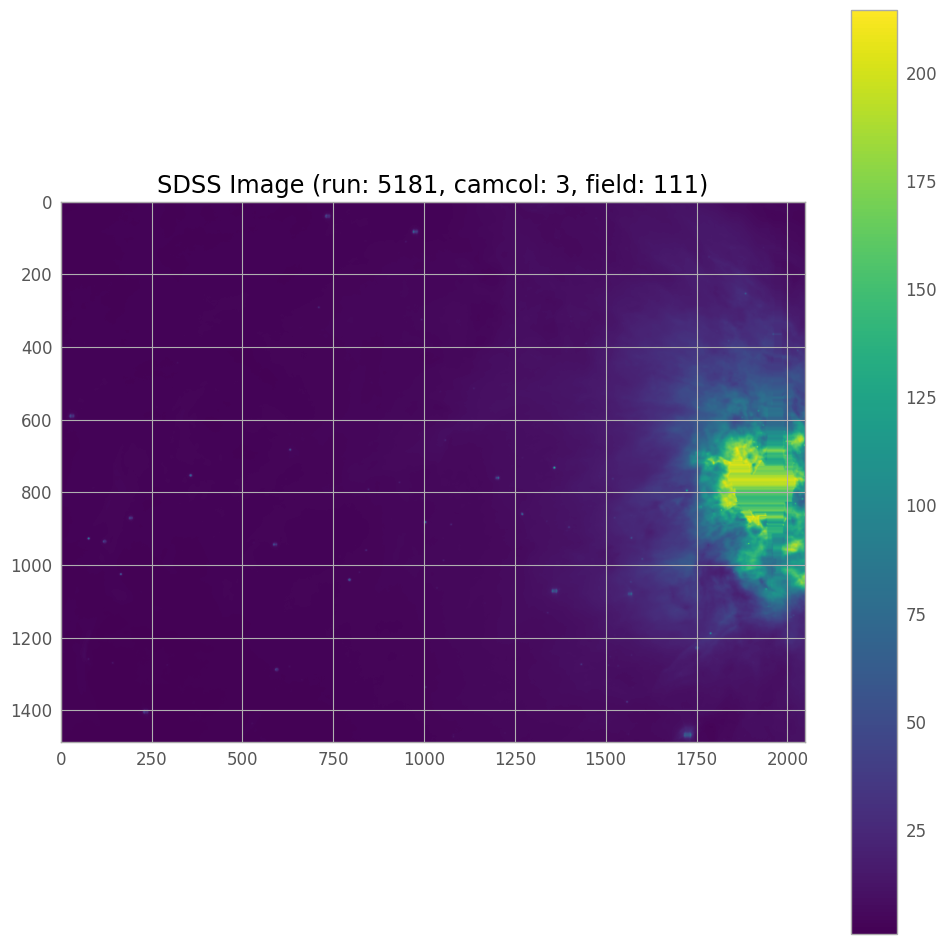

In [ ]:
from astroquery.sdss import SDSS
from astropy import coordinates as coords
import astropy.units as u
import matplotlib.pyplot as plt
from astropy.visualization import astropy_mpl_style
plt.style.use(astropy_mpl_style)

# Define the SDSS parameters from the result table (example)
run = 5181
rerun = 301
camcol = 3
field = 111

# Query the image using the specific SDSS parameters
try:
    images = SDSS.get_images(run=run, rerun=rerun, camcol=camcol, field=field, band='g')

    # Display the first image result
    for image in images:
        plt.figure(figsize=(12, 12))
        plt.imshow(image[0].data, cmap='viridis')
        plt.colorbar()
        plt.title(f'SDSS Image (run: {run}, camcol: {camcol}, field: {field})')
        plt.show()

except Exception as e:
    print(f"An error occurred: {e}")

In [ ]:
from astroquery.sdss import SDSS
from astropy import coordinates as coords
import astropy.units as u
  is within their coverage
try:
# Define the coordinates of the Orion Nebula (or other object)
object_coords = coords.SkyCoord('05h35m17.3s -05d23m28s', unit=(u.hourangle, u.deg))

# Query SDSS to check if the object
    result_table = SDSS.query_region(object_coords, radius=2*u.arcmin)
    if result_table:
        print("Data is available for this region in SDSS.")
        print(result_table)
    else:
        print("No data found in SDSS for this region.")
except Exception as e:
    print(f"An error occurred: {e}")

IndentationError: unexpected indent (<ipython-input-4-7e114de8cb48>, line 9)

#### **FITS File**

In [ ]:
hdul = fits.open(image['access_url'], use_fsspec=True)

In [ ]:
# Print the file information
hdul.info()

Filename: <class 'fsspec.implementations.http.HTTPFile'>
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      77   (4554, 4576)   float32   


In [ ]:
#  Access the primary HDU (Header/Data Unit) to get the data
primary_hdu = hdul[0]
data = primary_hdu.data
print(primary_hdu.header) # Display the header to learn more about the file
print(repr(hdul[0].header))  # Science data HDU header

SIMPLE  =                    T / Fits standard                                  BITPIX  =                  -32 / Bits per pixel - floating point                NAXIS   =                    2 / Number of axes                                 NAXIS1  =                 4554 / X axis length                                  NAXIS2  =                 4576 / Y axis length                                  ORIGIN  = 'Spitzer Super-Mosaic Pipeline' / Origin of these image data          CREATOR = 'Spitzer Science Center' / Creator of this FITS file                                                                                                            / TIME AND EXPOSURE INFORMATION                                                                                                                       TELESCOP= 'Spitzer '           / Name of Telescope                              INSTRUME= 'IRAC    '           / Name of Instrument                             CHNLNUM =                    3 / Instrum

In [ ]:
# Close the FITS file
hdul.close()

#### **LOFAR (Low-Frequency Array)**

While Astropy and Astroquery are powerful tools for astronomical data access, they don't have direct built-in functionality for accessing LOFAR data. LOFAR data typically needs to be accessed through different means:

1. The primary way to access LOFAR data is through the LOFAR Long Term Archive (LTA), which requires:
   - Registration for an account
   - Using their web interface or API
   - The `dysco` or `hdf5` format files usually need specialized tools for handling

2. For programmatic access, you'd typically want to use:
   - The LTA API directly
   - LOFAR-specific Python tools like `lofarpy` or `LofarStMan`
   - The ASTRON VO Tools

Here's a basic example of how you might write a Python script to interact with LOFAR data once you have it:

```python
import numpy as np
from casacore import tables
import h5py

def read_lofar_measurement_set(ms_path):
    # Open the measurement set
    tab = tables.table(ms_path)
    
    # Get data columns
    data = tab.getcol('DATA')
    time = tab.getcol('TIME')
    ant1 = tab.getcol('ANTENNA1')
    ant2 = tab.getcol('ANTENNA2')
    
    return data, time, ant1, ant2
```

If you're specifically looking to work with LOFAR data, I'd recommend:
1. Start with the LOFAR Imaging Cookbook, which provides detailed instructions for data access and processing
2. Look into the LOFAR Surveys KSP (Key Science Project) data releases, which are more readily accessible
3. Consider using the LOFAR-specific software stack, which includes tools designed for handling their unique data formats and calibration requirements

Would you like more specific information about any of these approaches or help setting up a particular type of LOFAR data analysis?